In [2]:
import sys, importlib

from LoadResults import LoadResults
import plot_res as p
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


<AxesSubplot:xlabel='Time[s]', ylabel='ReTX'>

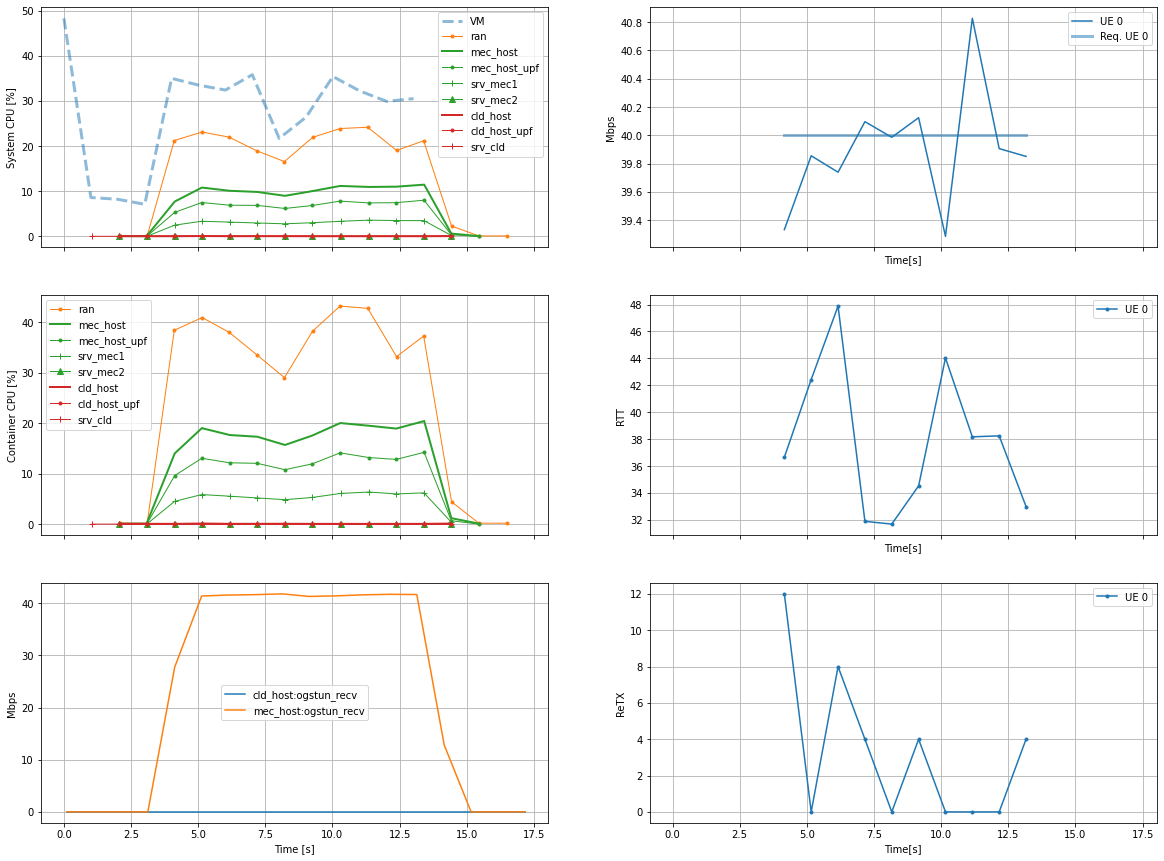

In [4]:
# res1 = LoadResults( f'../results/Prova.json' , load=True)

# print(res1.results)
res = p.load_results_json( f'../results/ProvaIperf.json' )


fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True , figsize=(20,15) )

p.plot_raw_cont_sys_cpu( res, ax[0][0], scen_idx=2)
p.plot_raw_cont_cpu(     res, ax[1][0], scen_idx=2)
p.plot_raw_upf_thr(      res, ax[2][0])

p.plot_raw_iperf_tcp_mbps_PerUe( res, ax[0][1] , ue="*", colors=p.get_color_list() )
p.plot_raw_iperf_tcp_rtt_PerUe(  res, ax[1][1] , ue="*", colors=p.get_color_list() )
p.plot_raw_iperf_tcp_retx_PerUe( res, ax[2][1] , ue="*", colors=p.get_color_list() )



,cpu:mec_host,cpu:cld_host,cpu:upf_mec,cpu:upf_cld,cpu:srv_mec1,cpu:srv_mec2,cpu:srv_cld,cld_host:ogstun_recv,mec_host:ogstun_recv
0 days 00:00:01,18.043301,5.168756,2.464549,0.001754,15.281235,0.006891,5.075108,0.0,2.750246
0 days 00:00:02,17.354028,2.237692,7.417050,0.001201,9.635172,0.007526,2.133052,0.0,8.333389
0 days 00:00:03,15.465762,0.044295,10.182555,0.002054,5.178266,0.004193,0.000823,0.0,10.288523
0 days 00:00:04,15.756506,0.050641,10.201856,0.002090,5.231549,0.003518,0.000874,0.0,10.573105
0 days 00:00:05,15.800069,0.070520,10.250650,0.005113,5.151331,0.007390,0.000871,0.0,10.462162


,cpu:mec_host,cpu:cld_host,cpu:upf_mec,cpu:upf_cld,cpu:srv_mec,cpu:srv_cld,cld_host:ogstun_recv,mec_host:ogstun_recv
0 days 00:00:01,19.780661,0.031979,1.717312,0.003388,17.472975,5.734420,0.0,2.531403
0 days 00:00:02,21.808856,7.789670,10.794778,0.000905,10.716599,3.176655,0.0,8.449428
0 days 00:00:03,20.486307,3.539439,14.333017,0.024236,6.025488,0.004133,0.0,10.483953
0 days 00:00:04,22.740043,0.094236,15.558310,0.013609,6.951126,0.002086,0.0,10.176266
0 days 00:00:05,21.659507,0.081552,14.595550,0.006969,7.041102,0.007087,0.0,10.491443


<AxesSubplot:xlabel='Time[s]', ylabel='ReTX'>

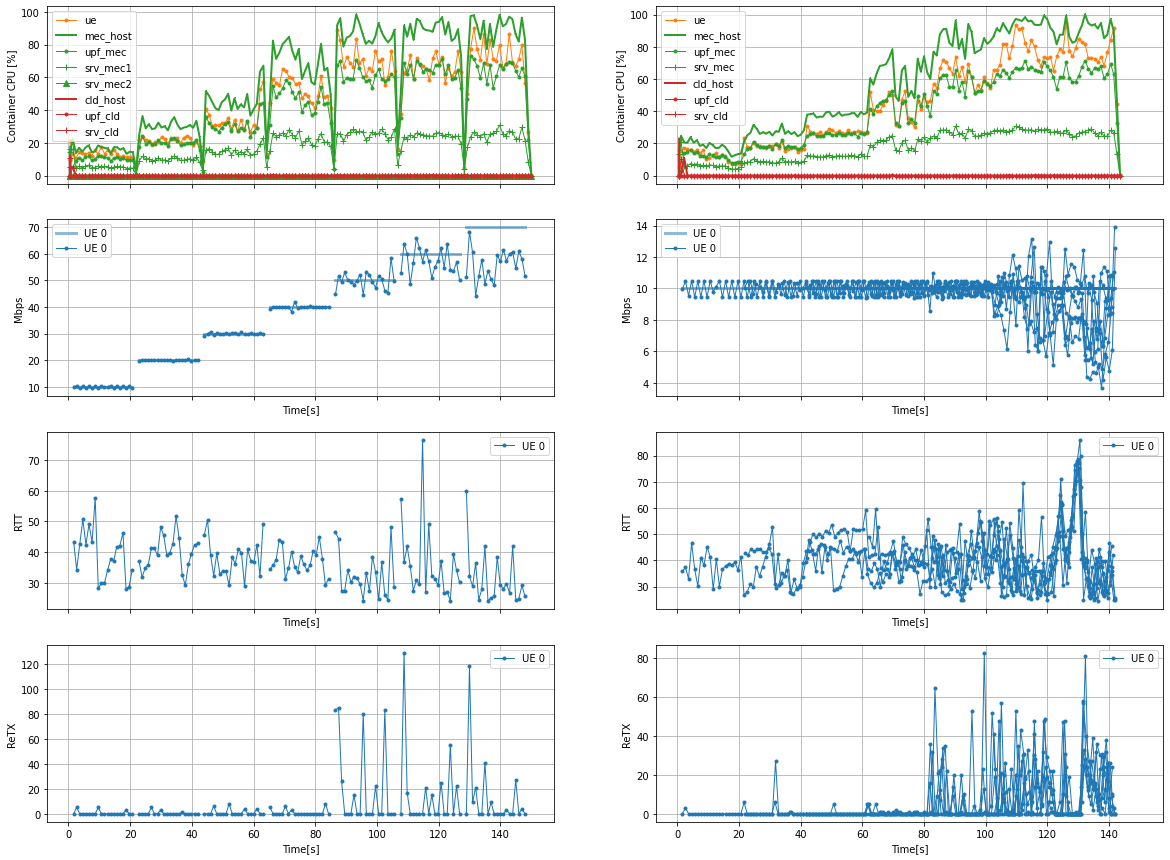

In [21]:
# COMPARE TWO SIMULATIONS
# res1 = Results( f'results/PerfHOST_scen1_tcp_mec_hostcpu1_nue1_sliceFalse.json', load=True)
# res2 = Results( f'results/PerfHOST_tcp_mec_hostcpu1_nue1_sliceFalse_continuousTX.json', load=True )
# res1 = Results( f'results/PerfHOST_tcp_mec_hostcpu0.7_nue1_sliceFalse.json', load=True)
# res2 = Results( f'results/PerfHOST_tcp_mec_hostcpu0.7_nue1_sliceFalse_continuousTX.json', load=True)
res1 = Results( f'results/PerfHOST_scen1_tcp_mec_hostcpu0.375_nue1_sliceFalse.json', load=True)
res2 = Results( f'results/PerfHOST_tcp_mec_hostcpu0.375_nue1_sliceFalse_continuousTX.json', load=True)
# res1 = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu0.375_nue1_sliceFalse.json', load=True)
# res2 = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu1_nue1_sliceFalse.json', load=True)

# display(res1.df.head())
# display(res2.df.head())

fig, ax = plt.subplots(nrows=4, ncols=2, sharex=True , figsize=(20,15) )
p.plot_raw_cont_cpu( res1, ax[0][0] , scen_idx=2)
p.plot_raw_cont_cpu( res2, ax[0][1] , scen_idx=1)
p.plot_raw_iperf_tcp_PerUe( res1, ax[1][0] , ue="*", kpi="req",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res1, ax[1][0] , ue="*", kpi="bwt",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res2, ax[1][1] , ue="*", kpi="req",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res2, ax[1][1] , ue="*", kpi="bwt",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res1, ax[2][0] , ue="*", kpi="rtt",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res2, ax[2][1] , ue="*", kpi="rtt",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res1, ax[3][0] , ue="*", kpi="retx",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res2, ax[3][1] , ue="*", kpi="retx",  colors=p.get_color_list() )
# ax[0][0].set_xlim(20,23)



(0.0, 110.0)

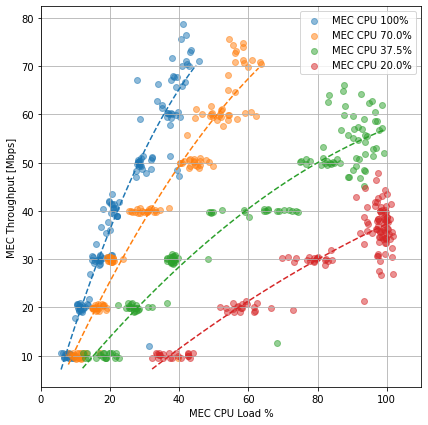

In [27]:
# SCATTER PLOT - MEC CPU vs. Throughput
colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
# xMax = [None,None,None,None]
# xMax = [None,None,65,40]
xMax = [None,75,60,35]

fig1, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(7,7) )

for hcpu in [ 1, 0.7, 0.375, 0.2]:
    c = next(colors_it)
    
    ##### SCENARIO 1a
    res = Results( f'results/PerfHOST_tcp_mec_hostcpu{hcpu}_nue1_sliceFalse_continuousTX.json', load=True )
    df_sum, _ = res.df_iperf_bwt( )
    res.df = res.df.join(df_sum, how="outer")
    p.plot_scatter(     res.df, ax1, "cpu:mec_host","iperf:ue0:bwt:sum", "MEC CPU Load %", "MEC Throughput [Mbps]", label=f"MEC CPU {hcpu*100}%" , color=c)
    p.plot_scatter_fit( res.df, ax1, "cpu:mec_host","iperf:ue0:bwt:sum", "MEC CPU Load %", "MEC Throughput [Mbps]", color=c)

    ##### SCENARIO 1b
    # res = Results( f'results/PerfHOST_scen1_tcp_mec_hostcpu{hcpu}_nue1_sliceFalse.json', load=True )
    # df_sum, _ = res.df_iperf_bwt( )
    # res.df = res.df.join(df_sum, how="outer")
    # p.plot_scatter(     res.df, ax1, "cpu:mec_host","iperf:ue0:bwt:sum", "MEC CPU Load %", "MEC Throughput [Mbps]", label=f"MEC CPU {hcpu*100}%" , color=c)
    # p.plot_scatter_fit( res.df, ax1, "cpu:mec_host","iperf:ue0:bwt:sum", "MEC CPU Load %", "MEC Throughput [Mbps]", color=c)

ax1.set_xlim(0,110)

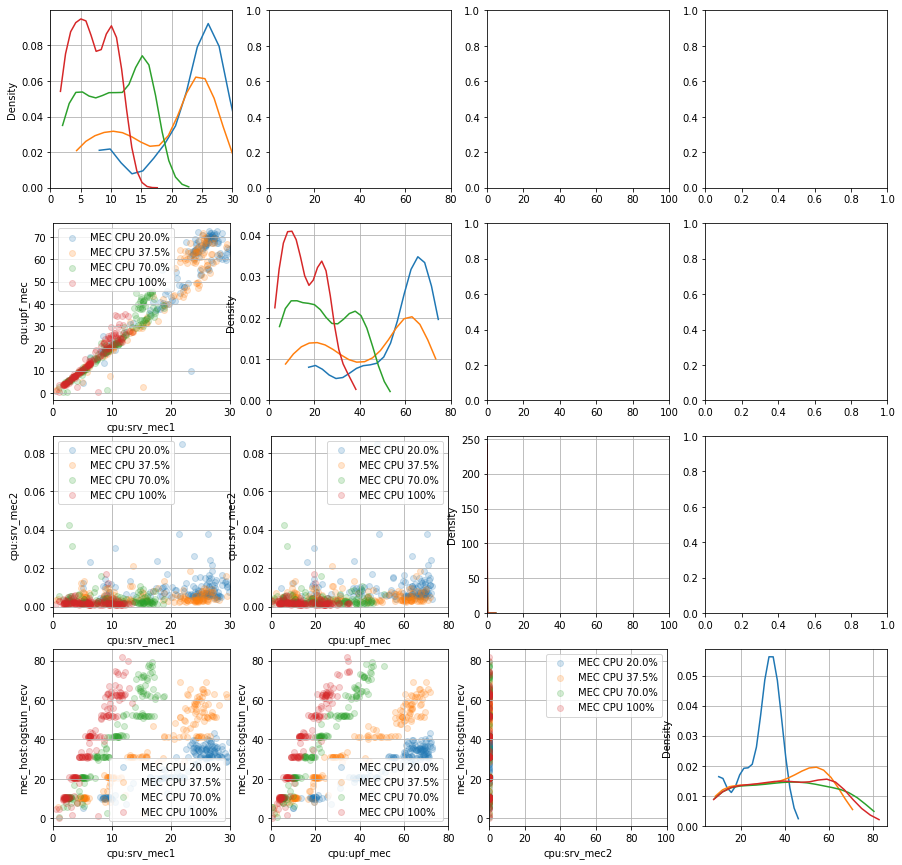

In [26]:
# Variables relation overview - SCENARIO 1

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
fig1, ax1   = plt.subplots( nrows=4, ncols=4, figsize=(15,15) )

# hcpu = [1, 0.7, 0.375, 0.2]
hcpu = [0.2, 0.375, 0.7, 1]
# hcpu = [1]
# hcpu = [0.7]
# hcpu = [0.375]
# hcpu = [0.2]

for i in range(len(hcpu)):
    c = next(colors_it)

    # cols = [ 'cpu:srv_mec','cpu:upf_mec','iperf:ue0:bwt:sum' ]
    # res = Results( f'results/PerfHOST_tcp_mec_hostcpu{hcpu[i]}_nue1_sliceFalse_continuousTX.json', load=True )
    cols = [ 'cpu:srv_mec1','cpu:upf_mec','cpu:srv_mec2','mec_host:ogstun_recv' ]
    res = Results( f'results/PerfHOST_scen1_tcp_mec_hostcpu{hcpu[i]}_nue1_sliceFalse.json', load=True )

    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df
    df = df.dropna()

    for row in range( len(cols) ):
        minv = min(df[cols[row]].values)-0
        maxv = max(df[cols[row]].values)+5
        interval = (maxv-minv)/20
        df[cols[row]].plot.density( ax=ax1[row,row], color=c, ind=[a for a in np.arange(minv,maxv,interval)])
        ax1[row,row].grid(visible=True)

        for col in range( len(cols) ):
            if col >= row:
                continue
            p.plot_scatter( res.df, ax1[row][col], cols[col],cols[row] , cols[col],cols[row] , label=f"MEC CPU {hcpu[i]*100}%" , color=c, alpha=0.2)

for row in range( len(cols) ):
    ax1[row,row].set_ylim(bottom=0,top=None)

for row in range( len(cols) ):
    ax1[row,0].set_xlim(left=0,right=30)
    ax1[row,1].set_xlim(left=0,right=80)
    ax1[row,2].set_xlim(left=0,right=100)

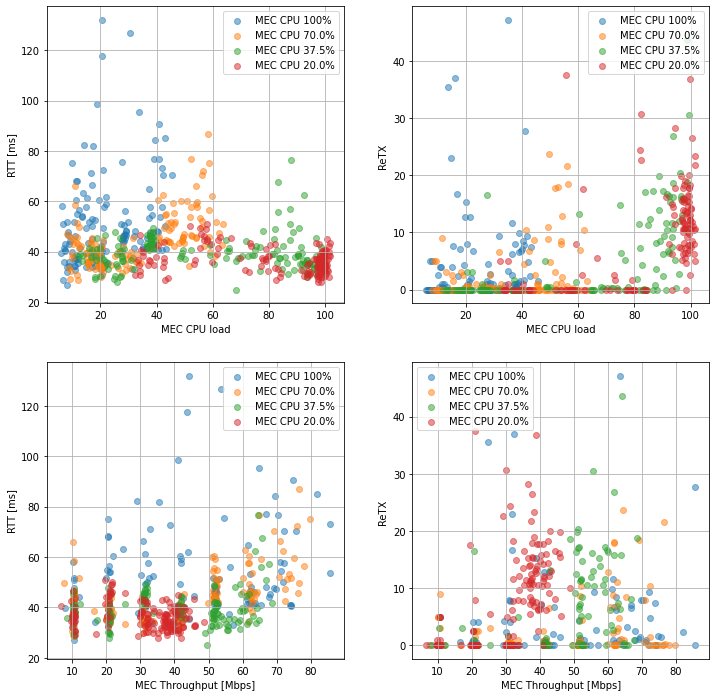

In [15]:
# SCATTER PLOT - RTT / ReTX
colors_it = itertools.cycle( ["C0","C1","C2","C3"] )

fig2, ax2 = plt.subplots(nrows=2, ncols=2, figsize=(12,12) )
cnt = 0
for hcpu in [ 1, 0.7, 0.375, 0.2]:
# for hcpu in [ 1 ]:
    c = next(colors_it)
    res = Results( f'results/PerfHOST_tcp_mec_hostcpu{hcpu}_nue1_sliceFalse_continuousTX.json', load=True )
    # res = Results( f'results/PerfHOST_scen1_tcp_mec_hostcpu{hcpu}_nue1_sliceFalse.json', load=True )
    df_sum, _ = res.df_iperf_bwt( )
    res.df = res.df.join(df_sum, how="outer")
    df_mean = res.df_iperf_rtt( )
    res.df = res.df.join(df_mean, how="outer")
    df_sum, df_mean = res.df_iperf_retx( )
    res.df = res.df.join(df_mean, how="outer")
    res.df = res.df.join(df_sum, how="outer")

    p.plot_scatter( res.df, ax2[0][0], "cpu:mec_host"      , "iperf:ue0:rtt:mean", "MEC CPU load"         , "RTT [ms]", label=f"MEC CPU {hcpu*100}%" , color=c)
    # p.plot_scatter( res.df, ax2[1][0], "iperf:ue0:bwt:sum" , "iperf:ue0:rtt:mean", "Iperf Throughput [Mbps]", "RTT [ms]", label=f"MEC CPU {hcpu*100}%" , color=c)
    p.plot_scatter( res.df, ax2[1][0], "mec_host:ogstun_recv" , "iperf:ue0:rtt:mean", "MEC Throughput [Mbps]", "RTT [ms]", label=f"MEC CPU {hcpu*100}%" , color=c)
    p.plot_scatter( res.df, ax2[0][1], "cpu:mec_host"      , "iperf:ue0:retx:mean", "MEC CPU load"          ,"ReTX ", label=f"MEC CPU {hcpu*100}%" , color=c)
    # p.plot_scatter( res.df, ax2[1][1], "iperf:ue0:bwt:sum" , "iperf:ue0:retx:sum", "Iperf Throughput [Mbps]" ,"ReTX ", label=f"MEC CPU {hcpu*100}%" , color=c)
    p.plot_scatter( res.df, ax2[1][1], "mec_host:ogstun_recv" , "iperf:ue0:retx:mean", "MEC Throughput [Mbps]" ,"ReTX ", label=f"MEC CPU {hcpu*100}%" , color=c)
    cnt += 1


(0.0, 100.0)

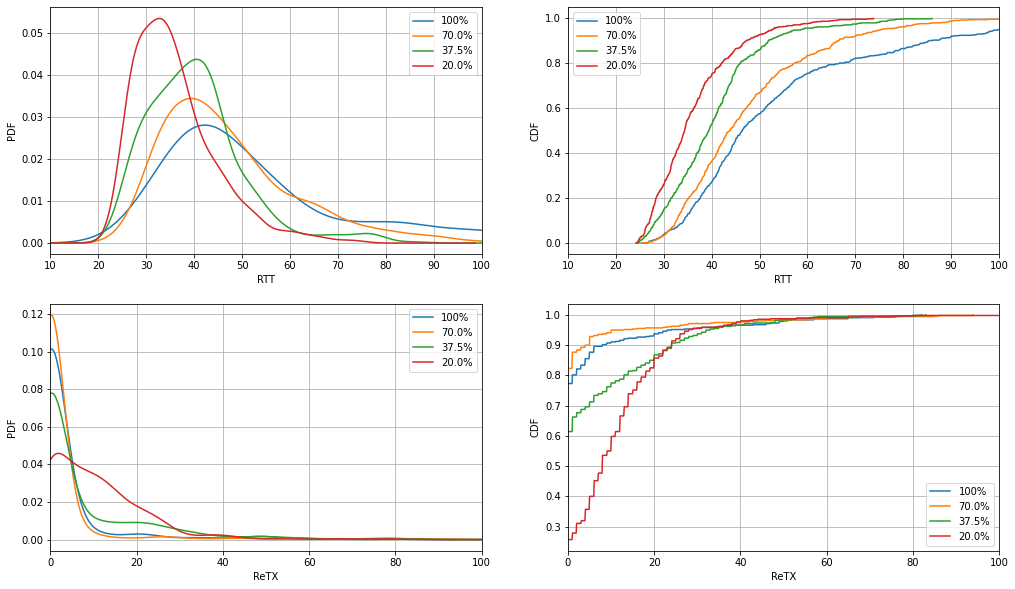

In [28]:
# Plot PDF and CDF of RTT and ReTX
colors_it = itertools.cycle( ["C0","C1","C2","C3"] )

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(17,10) )
for hcpu in [1,0.7,0.375,0.2]:
    c = next(colors_it)
    res1 = Results( f'results/PerfHOST_tcp_mec_hostcpu{hcpu}_nue1_sliceFalse_continuousTX.json', load=True )
    # res1 = Results( f'results/PerfHOST_scen1_tcp_mec_hostcpu{hcpu}_nue1_sliceFalse.json', load=True )
    p.plot_pdf( res1.get_iperf_rawdf_collapsed(ue_id=0,kpi="rtt") , col_name='iperf:ue0:rtt' , x_lab="RTT" , y_lab="PDF", ax=ax[0][0], label=f'{hcpu*100}%', color=c )
    p.plot_cdf( res1.get_iperf_rawdf_collapsed(ue_id=0,kpi="rtt") , col_name='iperf:ue0:rtt' , x_lab="RTT" , y_lab="CDF", ax=ax[0][1], label=f'{hcpu*100}%', color=c )
    p.plot_pdf( res1.get_iperf_rawdf_collapsed(ue_id=0,kpi="retx"), col_name='iperf:ue0:retx', x_lab="ReTX", y_lab="PDF", ax=ax[1][0], label=f'{hcpu*100}%', color=c )
    p.plot_cdf( res1.get_iperf_rawdf_collapsed(ue_id=0,kpi="retx"), col_name='iperf:ue0:retx', x_lab="ReTX", y_lab="CDF", ax=ax[1][1], label=f'{hcpu*100}%', color=c )
ax[0][0].set_xlim( 10, 100 )
ax[0][1].set_xlim( 10, 100 )
ax[1][0].set_xlim(  0, 100 )
ax[1][1].set_xlim(  0, 100 )
